# **Gaussian Convolution — interactive demo (users)**

## Libraries

In [1]:
import numpy as np, matplotlib.pyplot as plt, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

from core.config import LayoutConfig, GlobalConfig
from operators.image_io import ImageIO
from operators.gaussian import conv
from utils.nd_tools import show_plane  # helper for plane visualization
from utils.decorators import timer # helper for benchmarking

## Configurations

In [2]:
# ImageIO configuration: NumPy input/output, HWC layout
layout_cfg = LayoutConfig(layout_name="HWC", layout_framework="numpy", layout_ensured_name="HWC")
global_cfg  = GlobalConfig(framework="numpy", output_format="numpy")
io = ImageIO(layout_cfg=layout_cfg, global_cfg=global_cfg)

print("Initialized ImageIO — framework:", global_cfg.framework, "| output:", global_cfg.output_format)

Initialized ImageIO — framework: numpy | output: numpy


## Image Directory

In [3]:
root = Path.cwd().parent.parent.parent / "03_EXAMPLES_DATA" / "Images"
images_path = sorted([str(p) for p in root.rglob("*.png")])
rand = random.randint(0, len(images_path) - 2)
print("Found images:", len(images_path))

Found images: 672


## Load random image and build runners

In [4]:
image = io.read_image(images_path[rand], framework="numpy")

def run_conv(strat, proc, fw="numpy", out="numpy", dim=2, backend='sequential'):
    @timer(return_result=True, 
           name = "Convolve" + "_" + strat + "_" + proc)
    def _runner(img=image, dim=dim, size=None, sigma=2.0, angle=0):
        return conv(img, dim, size, sigma, angle, framework=fw, output_format=out, 
                    conv_strategy=strat, processor_strategy=proc, backend=backend,)
    return _runner

vectorized_   = run_conv("gaussian", "vectorized", fw="numpy")
classic_   = run_conv("fft", "classic", fw="numpy")
torch_  = run_conv("torch", "torch", fw="torch", out="numpy")
parallel_ = run_conv("gaussian", "parallel", fw="numpy", backend="threading")

vec_res, vec_k  = vectorized_(image)
fft_res, fft_k  = classic_(image)
torch_res, torch_k = torch_(image)
par_res, par_k  = parallel_(image)

print("Done: gaussian(vectorized), fft(classic), torch(torch), gaussian(parallel).")

Execution time for 'Convolve_gaussian_vectorized': 0.590 seconds
Execution time for 'Convolve_fft_classic': 0.977 seconds
Execution time for 'Convolve_torch_torch': 1.086 seconds
Execution time for 'Convolve_gaussian_parallel': 0.377 seconds
Done: gaussian(vectorized), fft(classic), torch(torch), gaussian(parallel).


## Visualisation

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7146776e-07..0.96847004].


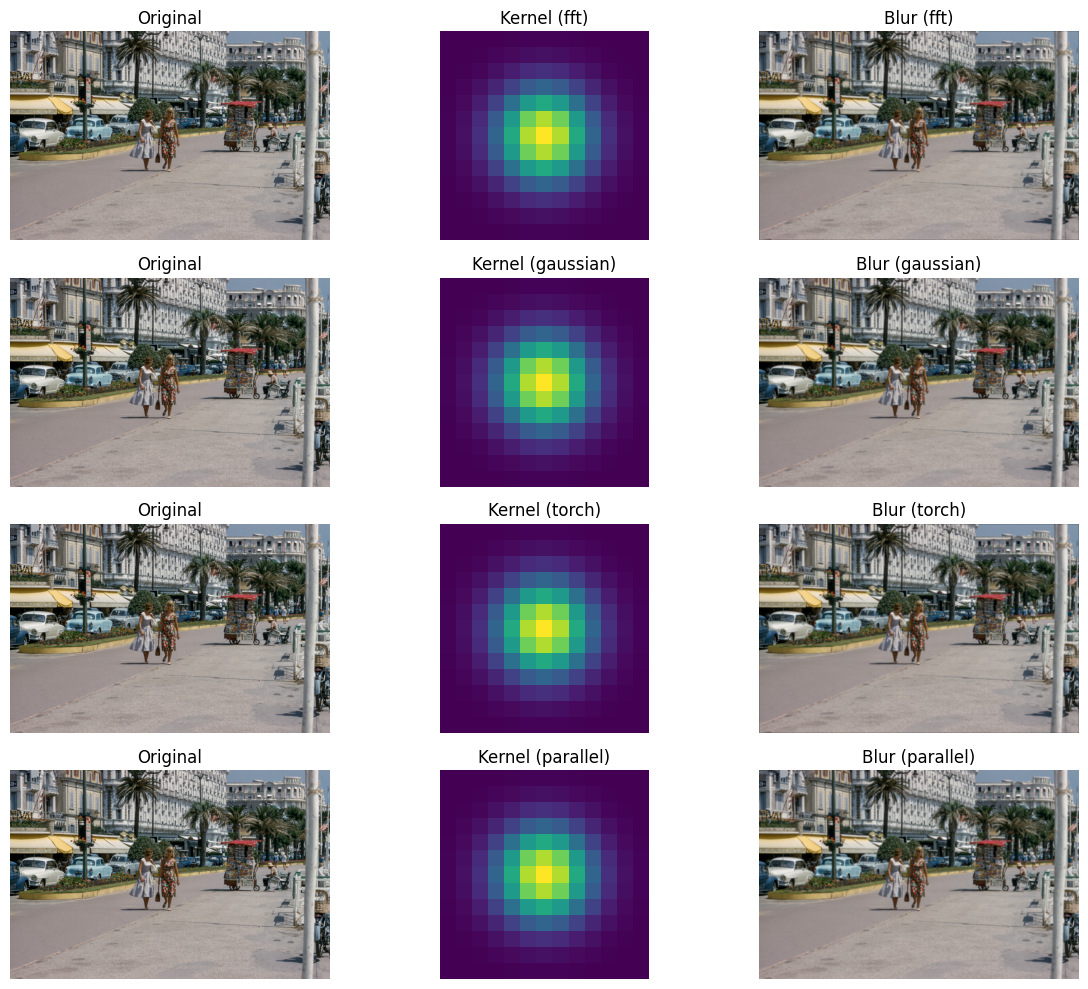

In [5]:
fig, axes = plt.subplots(4, 3, figsize=(12, 10))
(a,b,c), (d,e,f), (g,h,i), (j,k,l) = axes

show_plane(a, image,          title="Original")
show_plane(b, fft_k,          title="Kernel (fft)")
show_plane(c, fft_res,        title="Blur (fft)")

show_plane(d, image,          title="Original")
show_plane(e, vec_k,          title="Kernel (gaussian)")
show_plane(f, vec_res,        title="Blur (gaussian)")

show_plane(g, image,          title="Original")
show_plane(h, torch_k,    title="Kernel (torch)")
show_plane(i, torch_res,  title="Blur (torch)")

show_plane(j, image,          title="Original")
show_plane(k, par_k,          title="Kernel (parallel)")
show_plane(l, par_res,        title="Blur (parallel)")

plt.tight_layout(); plt.show()